<a href="https://colab.research.google.com/github/AlvaTF/TP-AA1-Ruiz-Toledo-Mendoza/blob/train-test/TP_1/TP-regresion-AA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Trabajo Práctico N° 1
####  Predicción de precios de casas

**Características de entrada en orden:**
1) CRIM: tasa de criminalidad per cápita por ciudad
2) ZN: proporción de terrenos residenciales zonificados para lotes de más de 25,000 pies
cuadrados
3) INDUS: proporción de acres de negocios no minoristas por ciudad
4) CHAS: variable dummy del río Charles (1 si el tramo limita con el río; 0 de lo contrario)
5) NOX: concentración de óxidos de nitrógeno (partes por 10 millones) [parts/10M]
6) RM: número promedio de habitaciones por vivienda
7) AGE: proporción de unidades ocupadas por sus propietarios construidas antes de 1940
8) DIS: distancias ponderadas a cinco centros de empleo de Boston
9) RAD: índice de accesibilidad a las autopistas radiales
10) TAX: tasa de impuesto sobre la propiedad a valor completo por $10,000 [$/10k]
11) PTRATIO: proporción alumno-maestro por ciudad
12) B: El resultado de la ecuación B=1000(Bk - 0.63)^2 donde Bk es la proporción de negros
por ciudad
13) LSTAT: % de población de menor estatus socioeconómico

**Variable de salida (target):**

14) MEDV: Valor mediano de las viviendas ocupadas por sus propietarios en miles de dólares

**Qué representa cada registro (fila):**

Cada fila es un tramo censal del área metropolitana de Boston: un barrio o sector de unas pocas miles de personas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_orig = pd.read_csv("house-prices-tp.csv")
print(f" Dataset de {data_orig.shape[0]:,} Registros con {data_orig.shape[1]} características")

 Dataset de 556 Registros con 14 características


#### Estructura del dataset original

In [3]:
print(f"\nPrimeras filas:")
data_orig.head()


Primeras filas:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


In [4]:
print(f"\nTipos de datos:")
data_orig.dtypes


Tipos de datos:


CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

#### Valores nulos

In [5]:
print(f"Valores nulos:")
print(data_orig.isnull().sum().sort_values(ascending=False))

print(f"\nPorcentaje de nulos por columna:")
print((data_orig.isna().mean()*100).round(2).sort_values(ascending=False))

print(f"\nCantidad de registros totalmente nulos:")
print(len(data_orig[data_orig.isna().all(axis=1)])) #eliminar

print("\nFilas sin MEDV:", data_orig['MEDV'].isnull().sum()) #eliminar

Valores nulos:
PTRATIO    28
RAD        28
NOX        24
AGE        24
CHAS       23
CRIM       23
LSTAT      22
B          22
ZN         22
RM         21
MEDV       21
TAX        18
INDUS      15
DIS        15
dtype: int64

Porcentaje de nulos por columna:
PTRATIO    5.04
RAD        5.04
NOX        4.32
AGE        4.32
CHAS       4.14
CRIM       4.14
LSTAT      3.96
B          3.96
ZN         3.96
RM         3.78
MEDV       3.78
TAX        3.24
INDUS      2.70
DIS        2.70
dtype: float64

Cantidad de registros totalmente nulos:
1

Filas sin MEDV: 21


#### Eliminacion de filas nulas o sin MEDV

Se descartan las filas sin target (MEDV) porque no se puede evaluar ni entrenar supervisado sin etiqueta.

In [6]:
data_orig = data_orig.dropna(subset=['MEDV'])
data_orig = data_orig.dropna(how='all')
print(f"Dataset después de eliminar nulos: {data_orig.shape[0]:,} Registros con {data_orig.shape[1]} características")

print(f"\nValores nulos después de la limpieza:")
print(data_orig.isnull().sum().sort_values(ascending=False))

print(f"\nPorcentaje de nulos por columna:")
print((data_orig.isna().mean()*100).round(2).sort_values(ascending=False))

Dataset después de eliminar nulos: 535 Registros con 14 características

Valores nulos después de la limpieza:
RAD        12
CRIM       11
AGE        11
ZN         11
CHAS        9
NOX         9
LSTAT       9
B           9
TAX         9
PTRATIO     9
RM          7
DIS         5
INDUS       4
MEDV        0
dtype: int64

Porcentaje de nulos por columna:
RAD        2.24
CRIM       2.06
AGE        2.06
ZN         2.06
CHAS       1.68
NOX        1.68
LSTAT      1.68
B          1.68
TAX        1.68
PTRATIO    1.68
RM         1.31
DIS        0.93
INDUS      0.75
MEDV       0.00
dtype: float64


#### Descripciones generales

In [7]:
round(data_orig.describe(), 2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,524.00,524.00,531.00,526.00,526.00,528.00,524.00,530.00,523.00,526.00,526.00,526.00,526.00,535.00
mean,4.99,12.50,11.23,0.09,0.56,6.28,67.66,3.89,9.62,409.19,18.42,350.87,12.97,22.75
std,11.94,24.29,6.92,0.28,0.12,0.75,28.57,2.21,8.67,167.88,2.20,96.82,7.51,9.49
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.13,0.00,0.45,5.88,42.28,2.11,4.00,279.00,17.00,371.62,7.12,16.75
50%,0.29,0.00,9.69,0.00,0.54,6.20,76.50,3.32,5.00,334.00,19.00,390.94,11.46,21.20
75%,4.55,20.00,18.10,0.00,0.63,6.63,93.90,5.29,24.00,666.00,20.20,396.04,17.16,26.30
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


#### Visualizaciones

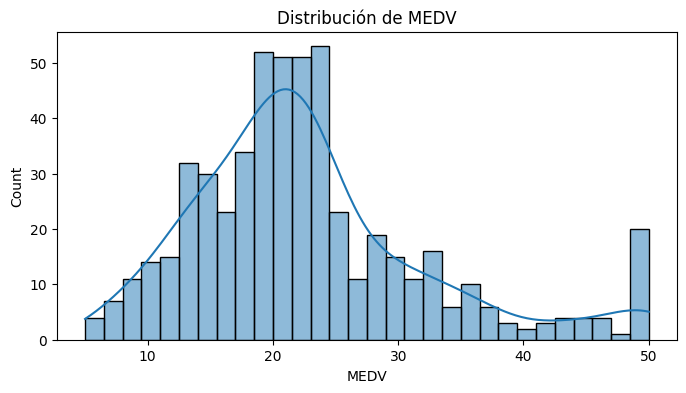

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(data_orig['MEDV'], kde=True, bins=30)
plt.title('Distribución de MEDV')
plt.show()

Los datos naturalmente presentan una distribucion practicamente normal. El problema es que parece haber un truncamiento en 50. Como se vio en la tabla anterior, este es el máximo valor presentado en el dataset. Se podría afirmar que a las casas que valian más de 50 (y permitian que la distribucion sea simetrica) se les asigno un límite de 50 por defecto.

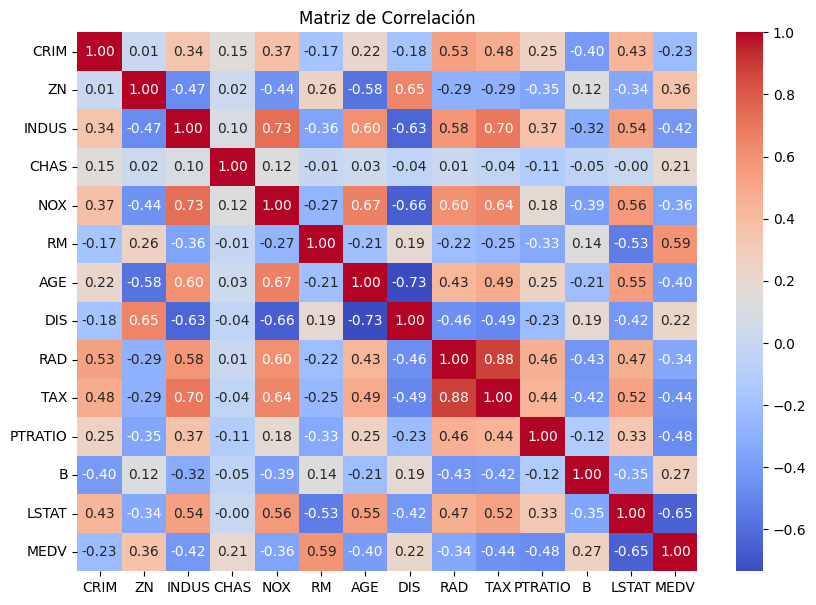

In [9]:
plt.figure(figsize=(10, 7))
sns.heatmap(data_orig.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

Multicolinealidad entre predictores, mayor a 0.70:
- Alta correlacion entre RAD y TAX (r=0.88)
- Entre NOX e INDUS (r=0.73)
- Entre TAX e INDUS (r=0.70).

Relacion alta con MEDV (target):
- RM tiene una alta relacion positiva (r=0.59) y LSTAT una alta relacion negativa (r=-0.65).

Se procede a verificar estas relaciones con **scatterploxs**:

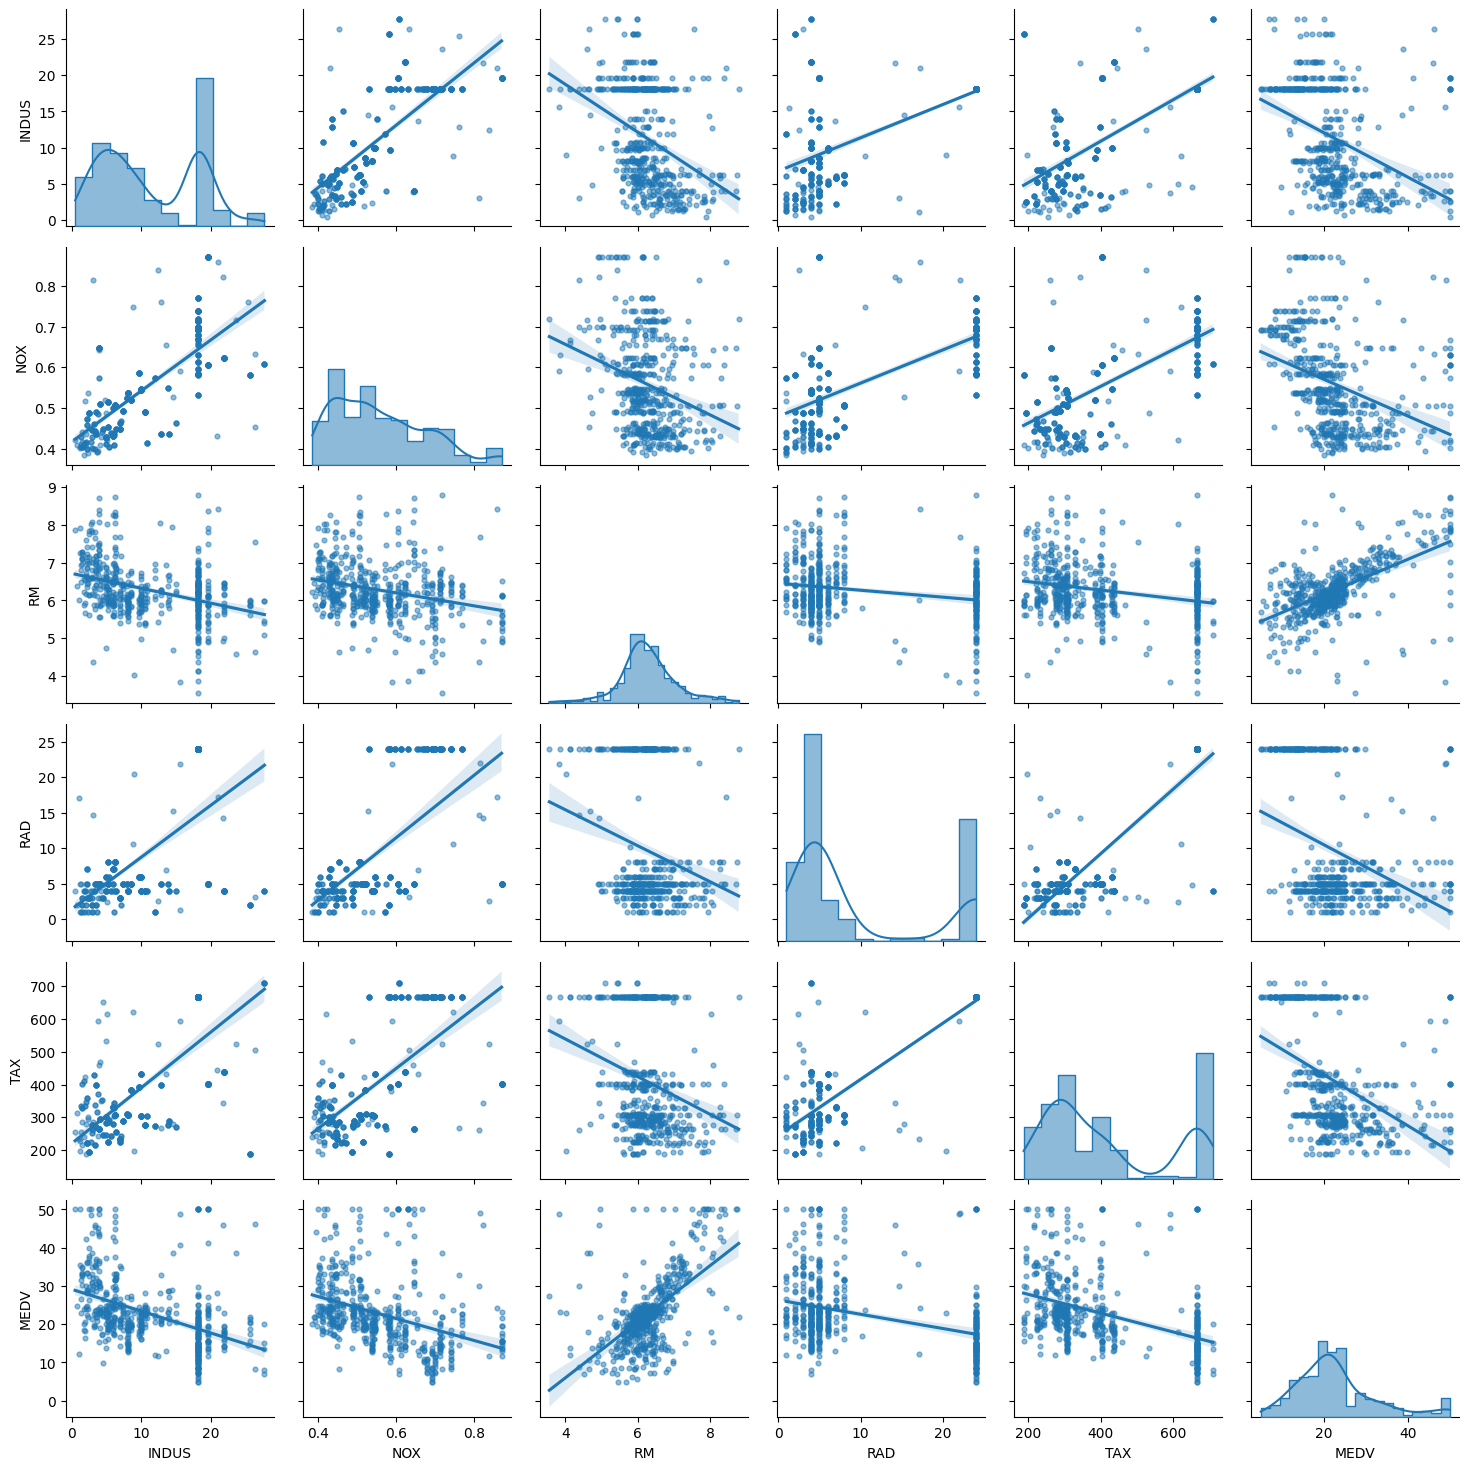

In [10]:
g = sns.PairGrid(data_orig[['INDUS', 'NOX', 'RM', 'RAD', 'TAX', 'MEDV']])
g.map_diag(sns.histplot, kde=True, element='step')
g.map_offdiag(sns.regplot, scatter_kws={'alpha': 0.5, 's': 12})

Detalles:
- Correlación entre RAD y TAX: hay dos grupos separados ya que hay una nube entre RAD 1-8 y otra columna en RAD=24, con un vacío total entre 8 y 24. La más fuerte es la primera.
- Entre NOX e INDUS: similar al anterior pero sin separaciones tan marcadas entre grupos.
- Entre TAX e INDUS: la nube sube de forma bastante continua en todo el rango, aunque también hay una concentración vertical en INDUS alrededor de 18 (más suelo industrial, más óxidos de nitrógeno)

#### Outliers

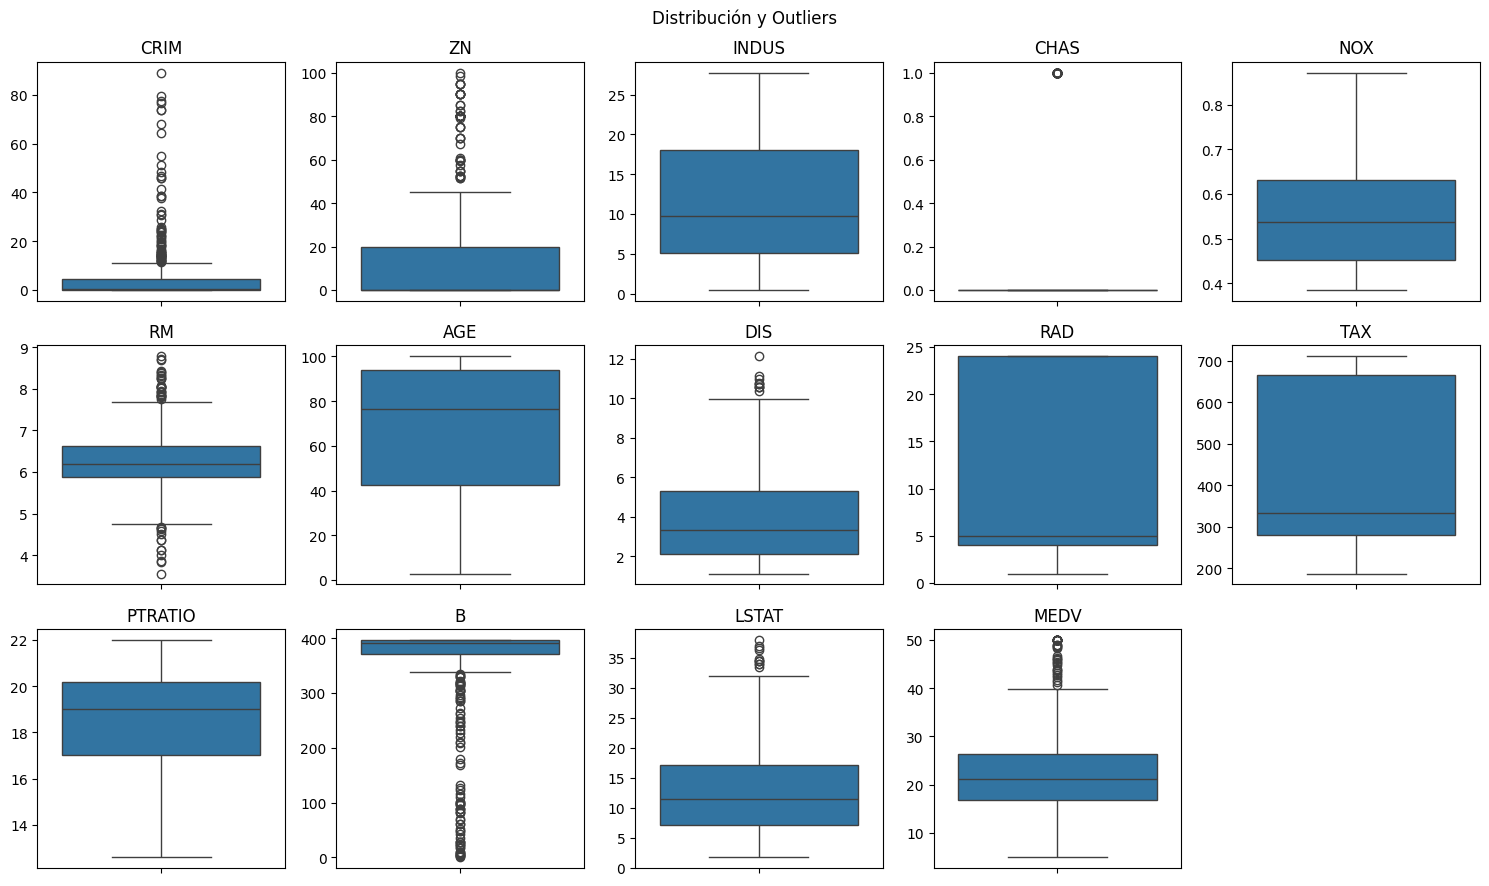

In [11]:
colum = data_orig.columns

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for ax, col in zip(axes.flat, colum):
    sns.boxplot(y=data_orig[col], ax=ax)
    ax.set_title(col)
    ax.set_ylabel('')

for ax in axes.flat[len(colum):]:
    ax.set_visible(False)

fig.suptitle('Distribución y Outliers')
plt.tight_layout()
plt.show()

**Variables con outliers notorios:**
- CRIM (tasa de criminalidad): valores máximos del bigote superior alrededor de 15. Los outliers pueden deberse a valores pertenecientes a zonas específicas de la ciudad. Se imputan nulos por mediana.
- ZN (proporción de terrenos residenciales zonificados de más de 25 mil pies cuadrados): mayoría de los valores en cero (o hasta 20%) y una cola larga de zonas residenciales exclusivas. Se evaluará si se imputan nulos por la mediana.
- CHAS (1 si el tramo limita con el río Charles; 0 de lo contrario): variable booleana. Lo único destacable es que la mayoría de los datos indican no limitar con el río. No se escala pero se imputarán nulos por moda.
- RM (promedio de habitaciones por vivienda): distribución con colas hacia ambos lados, lo que apunta a una distribución simétrica. Se presentan viviendas cuya mediana de cantidad de habitaciones ronda 6 pero se destacan algunas con menos de 5 y más de 8. Se escalará con StandardScaler y se imputarán nulos por media.
- B (proporción de habitantes negros): distribución sesgada a la izquierda, posiblemente documenta zonas con población negra. Posible imputación de nulos: por mediana.

#### Separacion de datos en train y test

In [12]:
from sklearn.model_selection import train_test_split
X = data_orig.drop('MEDV', axis=1)
y = data_orig['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(428, 13) (107, 13) (428,) (107,)


#### Escalado e imputacion con modelo LinearRegression

Los nulos de la mayor parte de las variables se imputarán con la mediana debido a la asimetría, salvo CHAS y RM (por moda y media, respectivamente) y presencia de outliers observados en el EDA.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression

In [14]:
imp_mediana = SimpleImputer(strategy="median")
imp_moda = SimpleImputer(strategy="most_frequent")
imp_media = SimpleImputer(strategy="mean")

In [15]:
cols_por_mediana = ['CRIM', 'ZN', 'INDUS', 'NOX', 'AGE', 'DIS', 'RAD', 'TAX','PTRATIO', 'B', 'LSTAT']
cols_por_media = ['RM']
cols_por_moda = ['CHAS']

In [ ]:
pipe_mediana = Pipeline([
    ('imputer', imp_mediana),
    ('scaler', StandardScaler())
])

pipe_media = Pipeline([
    ('imputer', imp_media),
    ('scaler', StandardScaler())
])

pipe_moda = Pipeline([
    ('imputer', imp_moda)
])

In [17]:
preprocesador = ColumnTransformer([
    ('mediana', pipe_mediana, cols_por_mediana),
    ('media', pipe_media, cols_por_media),
    ('moda', pipe_moda, cols_por_moda)
])

pipeline = Pipeline([
    ('preprocesador', preprocesador),
    ('model', LinearRegression())
])

# Ajustado de train
pipeline.fit(X_train, y_train)

# Evaluación en Test
y_pred = pipeline.predict(X_test)

In [18]:
# Comprobar que no hay valores nulos en el resultado
print("¿Hay nulos en las predicciones?:", np.isnan(y_pred).any())

# Comprobar la cantidad de predicciones
print("Cantidad de predicciones:", len(y_pred))

¿Hay nulos en las predicciones?: False
Cantidad de predicciones: 107


#### Validacion cruzada

In [19]:
from sklearn.model_selection import cross_val_score

# Validación cruzada (5 pliegues) sobre train
scores = cross_val_score(pipeline, X_train, y_train, cv=5)

# Resultados por pliegue
print(scores.round(3))

# Promedio y desvío estándar con el formato del ejemplo
print("%0.2f de score promedio, con una desviacion estandar de %0.2f" % (scores.mean(), scores.std()))

[0.615 0.451 0.739 0.661 0.624]
0.62 de score promedio, con una desviacion estandar de 0.09


El modelo LinearRegression obtuvo un R² promedio de 0.62 (+-0.10 de desvio) en validación cruzada con 5 folds. Esto indica que el modelo explica aproximadamente el 62% de la varianza en los precios de las casas, dejando un 38% sin explicar. Si bien este resultado es aceptable como punto de partida, hay oportunidad de mejora probando otros modelos y técnicas de regularización. La desviación estándar de 0.10 sugiere que el rendimiento varía según el subset de datos, indicando cierta inconsistencia del modelo frente a diferentes distribuciones de datos.